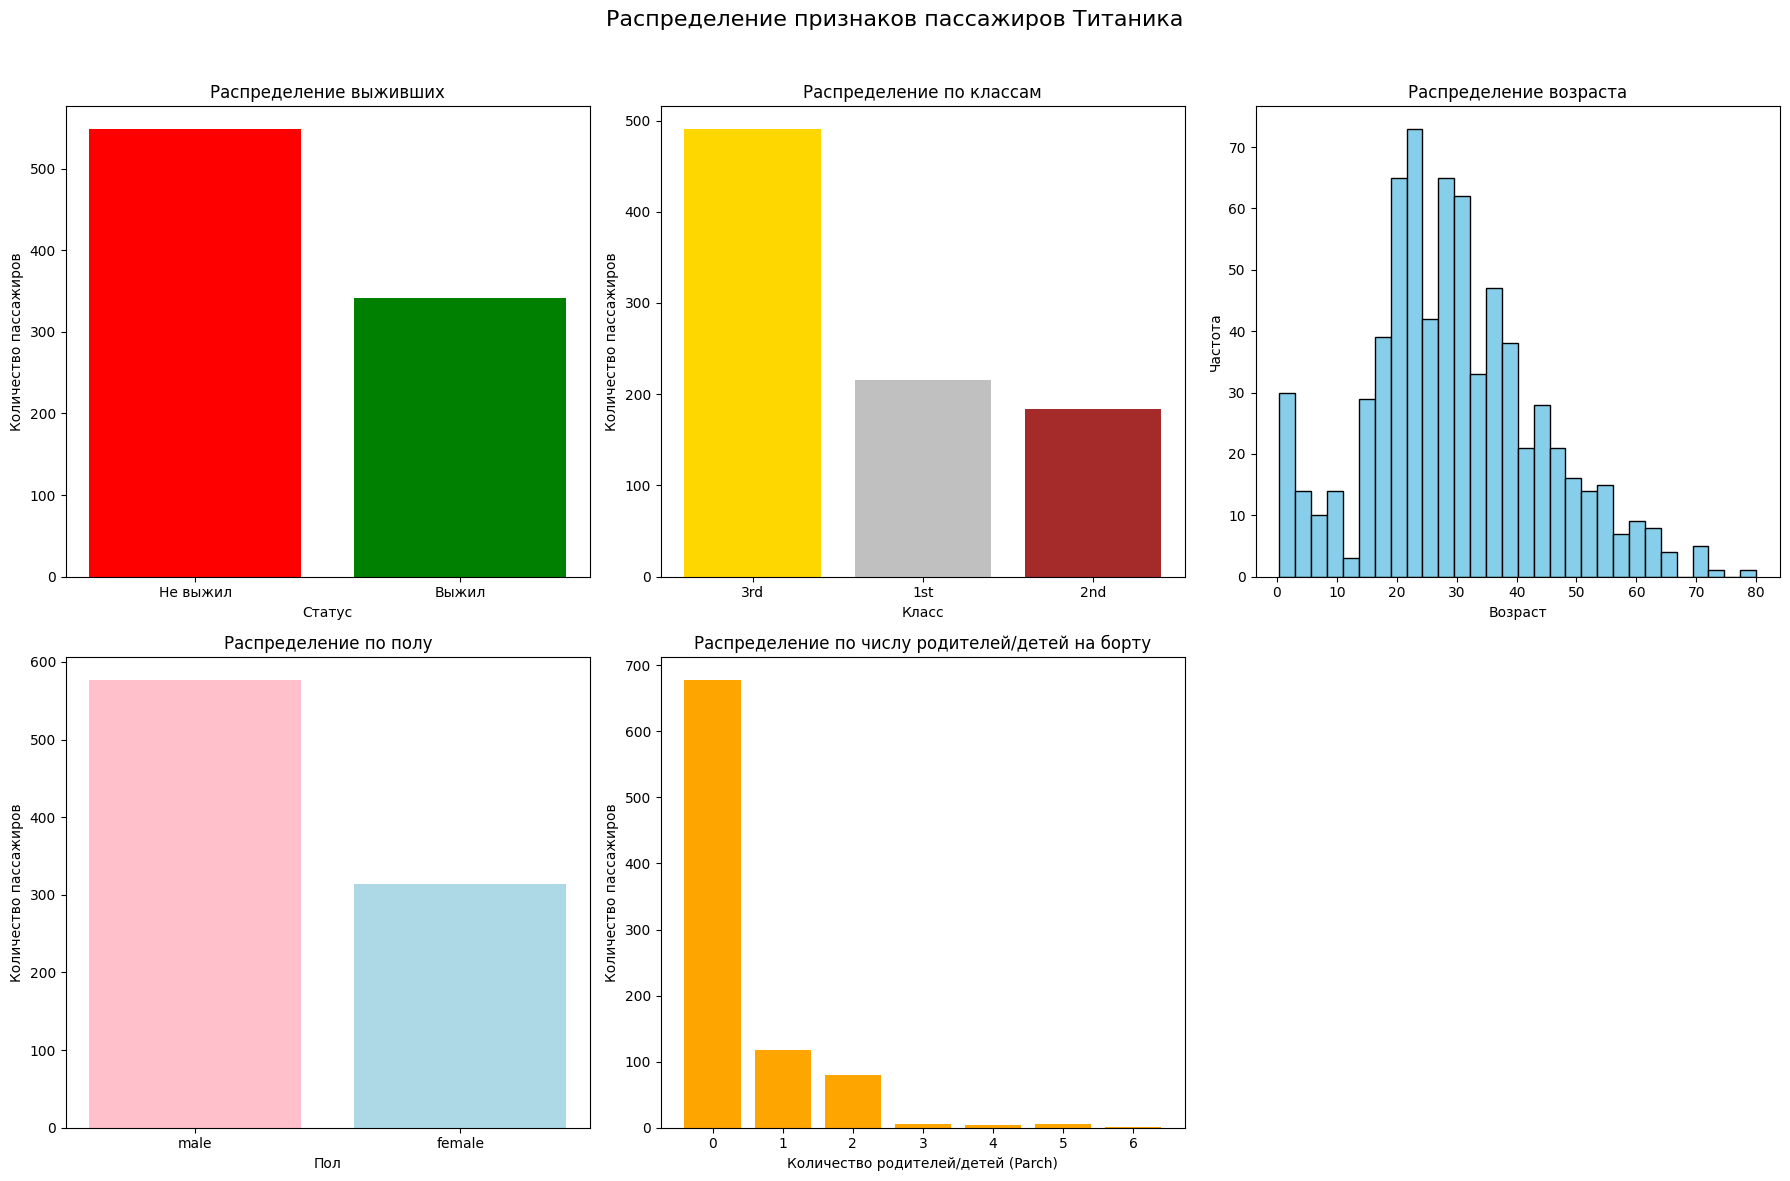

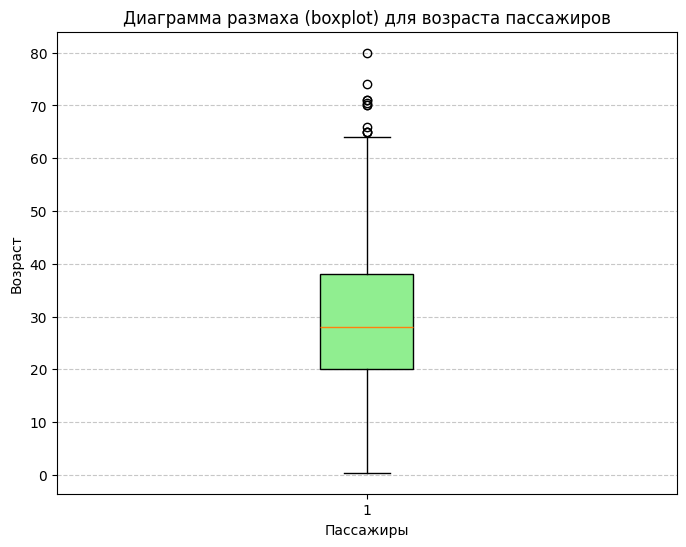


 Интерпретация boxplot для возраста:
- Средний возраст пассажиров составлял около 28 лет.
- 50% пассажиров находились ~ в возрасте от  20 до 38 лет.
- Средний возраст был около 30 лет.
- Присутствуют пассажиры как маленькие (до 0,5), так и взрослые (старше 70)
- Минимальный возраст был около 0.42 года (ребенок), максимальный - 80 лет.


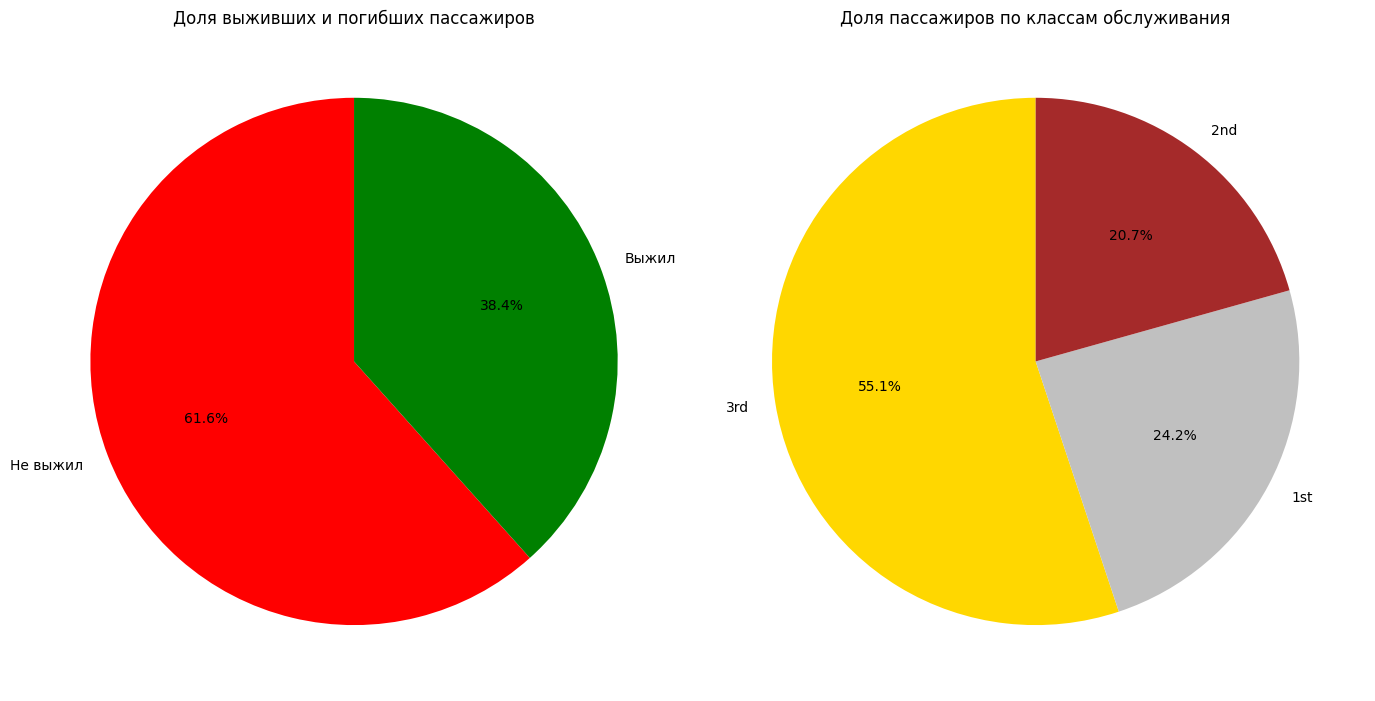

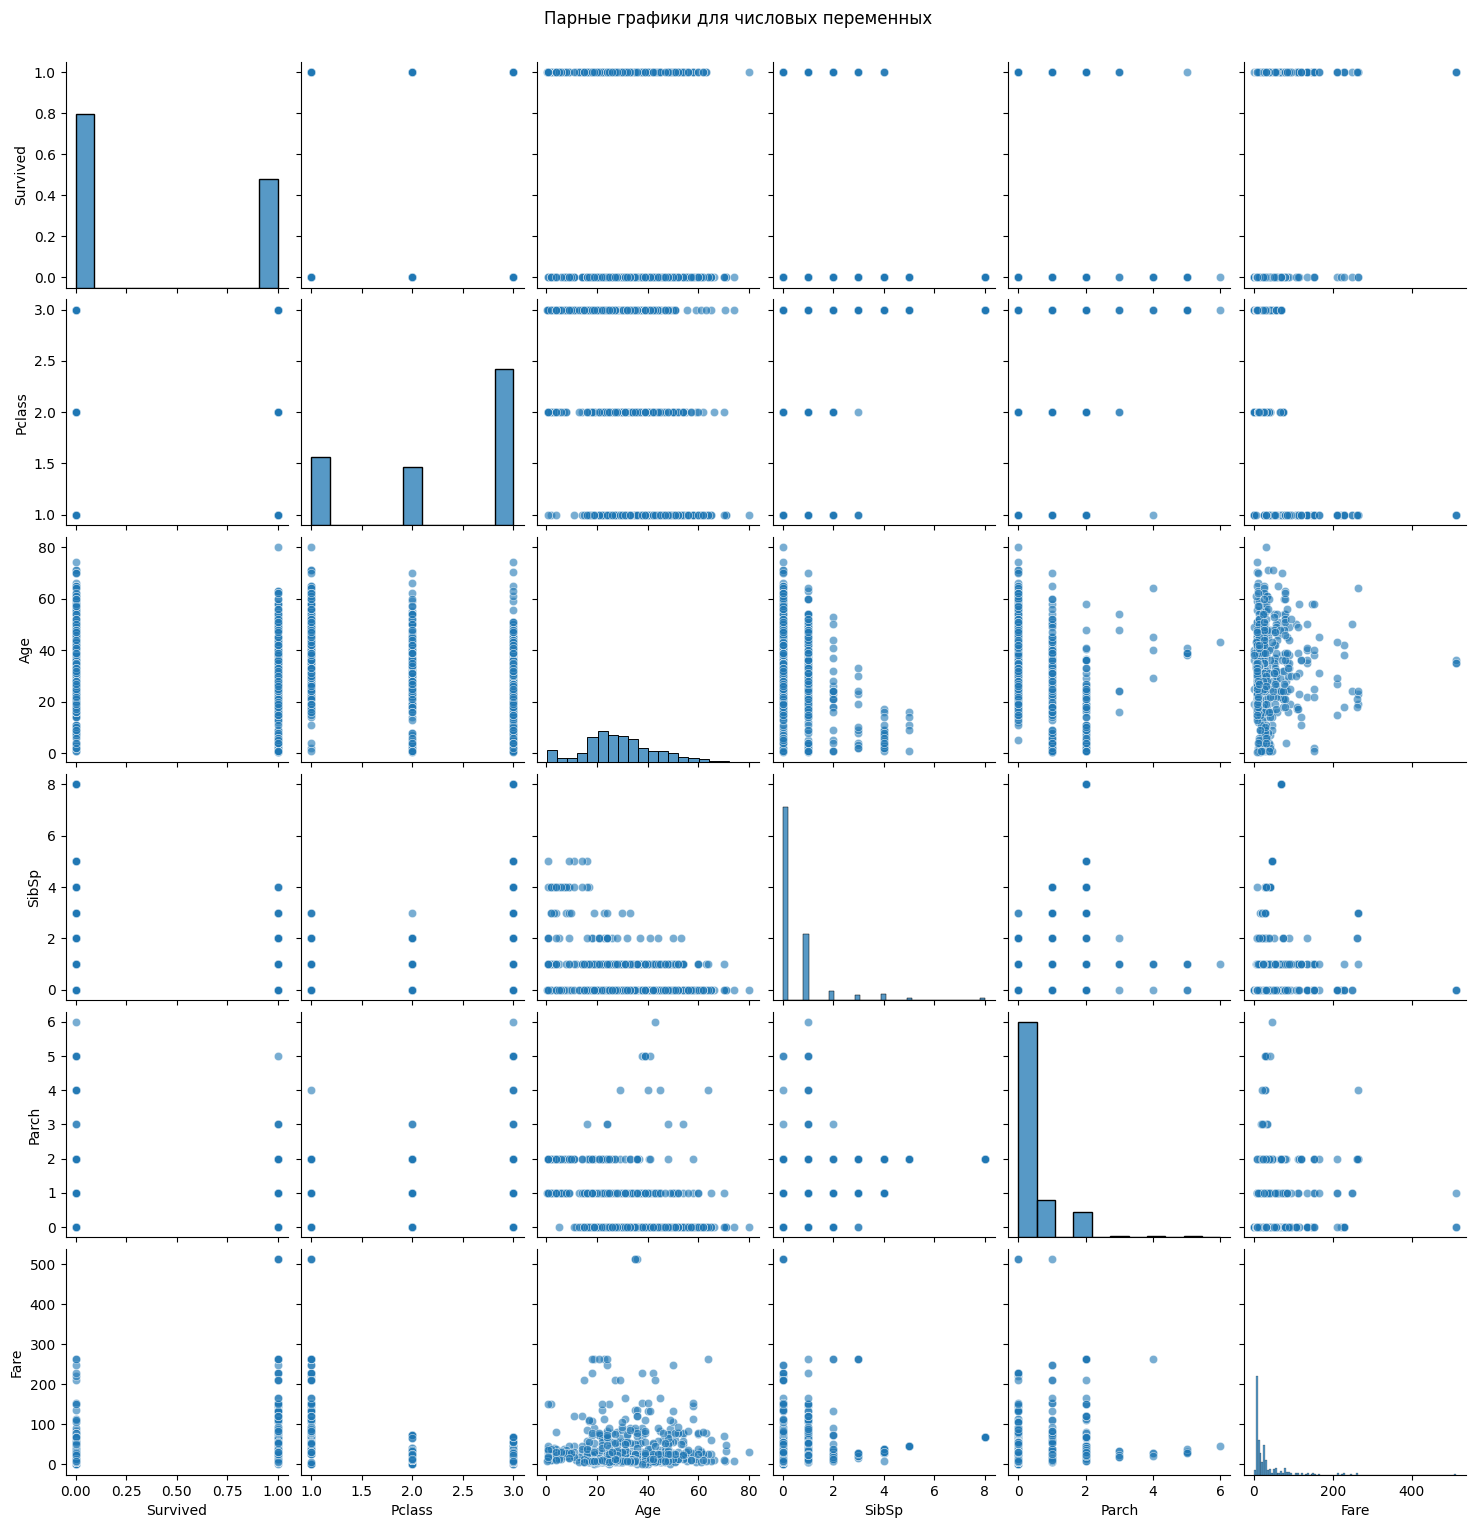


Дополнительная информация:
Общее количество пассажиров: 891
Количество выживших: 342 (38.4%)
Средний возраст: 29.7 лет
Медианный возраст: 28.0 лет
Средний тариф: $32.20


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

# 1. Считываем датасет из файла
df = pd.read_csv('train.csv')

# Заменим числовые значения в Survived на текст для лучшей интерпретации на графиках
df['Survived_label'] = df['Survived'].map({0: 'Не выжил', 1: 'Выжил'})
df['Pclass_label'] = df['Pclass'].map({1: '1st', 2: '2nd', 3: '3rd'})

# 2. Визуализируем распределение значений признаков Survived, Pclass, Age, Sex, Parch

# Создадим фигуру с подграфиками
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Распределение признаков пассажиров Титаника', fontsize=16)

# Survived
survived_counts = df['Survived_label'].value_counts()
axes[0, 0].bar(survived_counts.index, survived_counts.values, color=['red', 'green'])
axes[0, 0].set_title('Распределение выживших')
axes[0, 0].set_xlabel('Статус')
axes[0, 0].set_ylabel('Количество пассажиров')

# Pclass
pclass_counts = df['Pclass_label'].value_counts()
axes[0, 1].bar(pclass_counts.index, pclass_counts.values, color=['gold', 'silver', 'brown'])
axes[0, 1].set_title('Распределение по классам')
axes[0, 1].set_xlabel('Класс')
axes[0, 1].set_ylabel('Количество пассажиров')

# Age (уберем пропущенные значения для гистограммы)
axes[0, 2].hist(df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0, 2].set_title('Распределение возраста')
axes[0, 2].set_xlabel('Возраст')
axes[0, 2].set_ylabel('Частота')

# Sex
sex_counts = df['Sex'].value_counts()
axes[1, 0].bar(sex_counts.index, sex_counts.values, color=['pink', 'lightblue'])
axes[1, 0].set_title('Распределение по полу')
axes[1, 0].set_xlabel('Пол')
axes[1, 0].set_ylabel('Количество пассажиров')

# Parch
parch_counts = df['Parch'].value_counts().sort_index()
axes[1, 1].bar(parch_counts.index, parch_counts.values, color='orange')
axes[1, 1].set_title('Распределение по числу родителей/детей на борту')
axes[1, 1].set_xlabel('Количество родителей/детей (Parch)')
axes[1, 1].set_ylabel('Количество пассажиров')

# Очистим последний subplot
axes[1, 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 3. Построим график типа boxplot для столбца Age
plt.figure(figsize=(8, 6))
plt.boxplot(df['Age'].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Диаграмма размаха (boxplot) для возраста пассажиров')
plt.ylabel('Возраст')
plt.xlabel('Пассажиры')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Интерпретация boxplot:
print("\n Интерпретация boxplot для возраста:")
print("- Средний возраст пассажиров составлял около 28 лет.")
print("- 50% пассажиров находились ~ в возрасте от  20 до 38 лет.")
print("- Средний возраст был около 30 лет.")
print("- Присутствуют пассажиры как маленькие (до 0,5), так и взрослые (старше 70)")
print("- Минимальный возраст был около 0.42 года (ребенок), максимальный - 80 лет.")

# 4. Построим график типа pie chart для переменных Survived, Pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Pie chart для Survived
survived_counts = df['Survived_label'].value_counts()
axes[0].pie(survived_counts.values, labels=survived_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'green'])
axes[0].set_title('Доля выживших и погибших пассажиров')

# Pie chart для Pclass
pclass_counts = df['Pclass_label'].value_counts()
axes[1].pie(pclass_counts.values, labels=pclass_counts.index, autopct='%1.1f%%', startangle=90, colors=['gold', 'silver', 'brown'])
axes[1].set_title('Доля пассажиров по классам обслуживания')

plt.tight_layout()
plt.show()

# 5. Построим график типа pairplot для всех числовых переменных датасета
# Выберем числовые столбцы
numeric_columns = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
df_numeric = df[numeric_columns]

# Создадим pairplot
sns.pairplot(df_numeric, diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Парные графики для числовых переменных', y=1.02)
plt.show()

# 6. Построим интерактивный sunburst plot с помощью plotly
# Подготовим данные для sunburst plot
sunburst_data = df.groupby(['Pclass_label', 'Sex']).size().reset_index(name='count')

# Создадим sunburst plot
fig = px.sunburst(
    sunburst_data,
    path=['Pclass_label', 'Sex'],
    values='count',
    title='Иерархия пассажиров Титаника: Класс -> Пол',
    color='Pclass_label',
    color_discrete_map={'1st': 'gold', '2nd': 'silver', '3rd': 'brown'}
)

fig.update_traces(textinfo='label+percent parent')
fig.show()

# Дополнительная информация о датасете
print("\nДополнительная информация:")
print(f"Общее количество пассажиров: {len(df)}")
print(f"Количество выживших: {df['Survived'].sum()} ({df['Survived'].mean() * 100:.1f}%)")
print(f"Средний возраст: {df['Age'].mean():.1f} лет")
print(f"Медианный возраст: {df['Age'].median():.1f} лет")
print(f"Средний тариф: ${df['Fare'].mean():.2f}")
